In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
from PIL import Image

class EideticConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3, padding=1):
        super(EideticConvLSTMCell, self).__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 7 * hidden_dim, kernel_size, padding=padding, bias=True
        )
        self.memory_gate = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=1, padding=0, bias=True)

    def forward(self, x, h_prev, c_prev, m_prev):
        combined = torch.cat([x, h_prev], dim=1)
        conv_output = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g, cc_u, cc_r, cc_m = torch.split(conv_output, self.hidden_dim, dim=1)

        # Standard LSTM gates
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        # Memory cell update
        c_next = f * c_prev + i * g

        # Update memory
        u = torch.sigmoid(cc_u)
        r = torch.sigmoid(cc_r)
        memory_update = torch.tanh(cc_m)
        m_next = u * m_prev + r * memory_update

        # Eidetic gate
        eidetic_output = torch.sigmoid(self.memory_gate(m_next))
        c_eidetic = eidetic_output * c_next

        # Hidden state update
        h_next = o * torch.tanh(c_eidetic)
        return h_next, c_next, m_next


class EideticConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(EideticConvLSTM, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.layers = nn.ModuleList(
            [EideticConvLSTMCell(input_dim if i == 0 else hidden_dim, hidden_dim) for i in range(num_layers)]
        )

    def forward(self, x):
        b, _, h, w = x.size()
        h_states = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]
        c_states = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]
        m_states = [torch.zeros(b, self.hidden_dim, h, w, device=x.device) for _ in range(self.num_layers)]

        for i, layer in enumerate(self.layers):
            h_states[i], c_states[i], m_states[i] = layer(x, h_states[i], c_states[i], m_states[i])
            x = h_states[i]
        return x


# Define Channel Attention
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        # Ensure the output channels after reduction are at least 1
        reduced_channels = max(1, in_channels // reduction_ratio)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(in_channels, reduced_channels, kernel_size=1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(reduced_channels, in_channels, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.global_avg_pool(x)
        avg_out = self.fc1(avg_out)
        avg_out = self.relu(avg_out)
        avg_out = self.fc2(avg_out)
        return self.sigmoid(avg_out) * x


# Define Spatial Attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), "Kernel size must be 3 or 7"
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        mean_out = torch.mean(x, dim=1, keepdim=True)
        combined = torch.cat([max_out, mean_out], dim=1)
        attention = self.conv(combined)
        return x * self.sigmoid(attention)


# Define Encoder
class Encoder(nn.Module):
    def __init__(self, input_channels):
        super(Encoder, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  # Correct pooling

        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, input_channels, kernel_size=3, stride=1, padding=1),  # Maintain spatial size
            nn.BatchNorm2d(input_channels),
            nn.ReLU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(input_channels, input_channels * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(input_channels * 2),
            nn.ReLU(),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(input_channels * 2, input_channels * 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(input_channels * 4),
            nn.ReLU(),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(input_channels * 4, input_channels * 8, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(input_channels * 8),
            nn.ReLU(),
        )
        self.conv_lstm = EideticConvLSTM(input_channels * 8, input_channels * 8, num_layers=3)

    def forward(self, x):
        x1 = self.conv1(x)  # Output: (B, input_channels, H, W)
        x2 = self.conv2(self.pool(x1))  # Output: (B, input_channels * 2, H/2, W/2)
        x3 = self.conv3(self.pool(x2))  # Output: (B, input_channels * 4, H/4, W/4)
        x4 = self.conv4(self.pool(x3))  # Output: (B, input_channels * 8, H/8, W/8)
        x4 = self.conv_lstm(x4)  # Eidetic ConvLSTM: No spatial reduction
        return x1, x2, x3, x4


import torch.nn.functional as F

class Decoder(nn.Module):
    def __init__(self, output_channels):
        super(Decoder, self).__init__()
        # Upsample and Conv layers
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(output_channels * 8, output_channels * 4, kernel_size=3, padding=1),
        )
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(output_channels * 8, output_channels * 2, kernel_size=3, padding=1),
        )
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(output_channels * 4, output_channels, kernel_size=3, padding=1),
        )

        # Eidetic ConvLSTM Layers
        self.lstm4 = EideticConvLSTM(output_channels * 4, output_channels * 4, num_layers=3)
        self.lstm3 = EideticConvLSTM(output_channels * 2, output_channels * 2, num_layers=3)
        self.lstm2 = EideticConvLSTM(output_channels, output_channels, num_layers=3)

        # Attention modules
        self.channel_attention1 = ChannelAttention(output_channels * 8)
        self.spatial_attention1 = SpatialAttention()
        self.channel_attention2 = ChannelAttention(output_channels * 4)
        self.spatial_attention2 = SpatialAttention()
        self.channel_attention3 = ChannelAttention(output_channels * 2)
        self.spatial_attention3 = SpatialAttention()

        # Final convolution
        self.final_conv = nn.Conv2d(output_channels * 2, 3, kernel_size=3, padding=1)

    def forward(self, x1, x2, x3, x4):
        # Decoder Step 1: 32x32 -> 64x64
        x = self.up4(x4)
        x = self.lstm4(x)  # Eidetic ConvLSTM layer
        x = torch.cat([x, x3], dim=1)
        x = self.channel_attention1(x)
        x = self.spatial_attention1(x)

        # Decoder Step 2: 64x64 -> 128x128
        x = self.up3(x)
        x = self.lstm3(x)  # Eidetic ConvLSTM layer
        x = torch.cat([x, x2], dim=1)
        x = self.channel_attention2(x)
        x = self.spatial_attention2(x)

        # Decoder Step 3: 128x128 -> 256x256
        x = self.up2(x)
        x = self.lstm2(x)  # Eidetic ConvLSTM layer
        x = torch.cat([x, x1], dim=1)
        x = self.channel_attention3(x)
        x = self.spatial_attention3(x)

        # Final output
        return self.final_conv(x)


# Define Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_channels):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_channels)
        self.decoder = Decoder(input_channels)

    def forward(self, x):
        x1, x2, x3, x4 = self.encoder(x)
        x = self.decoder(x1, x2, x3, x4)
        return x

# Test
if __name__ == "__main__":
    input_channels = 3
    model = Autoencoder(input_channels)
    sample_input = torch.randn(1, input_channels, 256, 256)  # Batch size 1, RGB image
    output = model(sample_input)
    print("Input shape:", sample_input.shape)
    print("Output shape:", output.shape)



C:\Users\uceti\anaconda3\envs\CUDA-pytorch\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])


In [2]:
from torchsummary import summary

def count_trainable_params(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

# Initialize the model
input_channels = 3  # For RGB images
model = Autoencoder(input_channels=input_channels)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print the model summary
summary(model, input_size=(input_channels, 256, 256))

# Print the total trainable parameters
count_trainable_params(model)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 256, 256]              84
       BatchNorm2d-2          [-1, 3, 256, 256]               6
              ReLU-3          [-1, 3, 256, 256]               0
         MaxPool2d-4          [-1, 3, 128, 128]               0
            Conv2d-5          [-1, 6, 128, 128]             168
       BatchNorm2d-6          [-1, 6, 128, 128]              12
              ReLU-7          [-1, 6, 128, 128]               0
         MaxPool2d-8            [-1, 6, 64, 64]               0
            Conv2d-9           [-1, 12, 64, 64]             660
      BatchNorm2d-10           [-1, 12, 64, 64]              24
             ReLU-11           [-1, 12, 64, 64]               0
        MaxPool2d-12           [-1, 12, 32, 32]               0
           Conv2d-13           [-1, 24, 32, 32]           2,616
      BatchNorm2d-14           [-1, 24,

In [3]:
# Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.image_paths = list(self.data_dir.glob("*.png")) + list(self.data_dir.glob("*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, image  # Input and target are the same for autoencoder

# Gradient Loss
class GradientLoss(nn.Module):
    def __init__(self):
        super(GradientLoss, self).__init__()

    def forward(self, pred, target):
        grad_pred_x = torch.abs(pred[:, :, :, :-1] - pred[:, :, :, 1:])
        grad_pred_y = torch.abs(pred[:, :, :-1, :] - pred[:, :, 1:, :])
        grad_target_x = torch.abs(target[:, :, :, :-1] - target[:, :, :, 1:])
        grad_target_y = torch.abs(target[:, :, :-1, :] - target[:, :, 1:, :])
        return torch.mean(torch.abs(grad_pred_x - grad_target_x)) + torch.mean(torch.abs(grad_pred_y - grad_target_y))

# Training Code
if __name__ == "__main__":
    # Parameters
    input_channels = 3
    batch_size = 5
    learning_rate = 1e-4
    num_epochs = 10
    data_dir = r"C:\Users\uceti\Desktop\SIP\Datasets\Avenue\Normal\original\O1"

    # Model, Losses, and Optimizer
    model = Autoencoder(input_channels).cuda()
    criterion_mse = nn.MSELoss()
    criterion_grad = GradientLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Dataset and DataLoader
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
    dataset = CustomDataset(data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Training Loop
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for inputs, targets in dataloader:
            inputs, targets = inputs.cuda(), targets.cuda()

            # Forward Pass
            outputs = model(inputs)
            loss_mse = criterion_mse(outputs, targets)
            loss_grad = criterion_grad(outputs, targets)
            loss = loss_mse + loss_grad

            # Backward Pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

    print("Training Completed.")


Epoch [1/10], Loss: 0.1233
Epoch [2/10], Loss: 0.0624
Epoch [3/10], Loss: 0.0503
Epoch [4/10], Loss: 0.0464
Epoch [5/10], Loss: 0.0430
Epoch [6/10], Loss: 0.0400
Epoch [7/10], Loss: 0.0370
Epoch [8/10], Loss: 0.0341
Epoch [9/10], Loss: 0.0315
Epoch [10/10], Loss: 0.0293
Training Completed.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


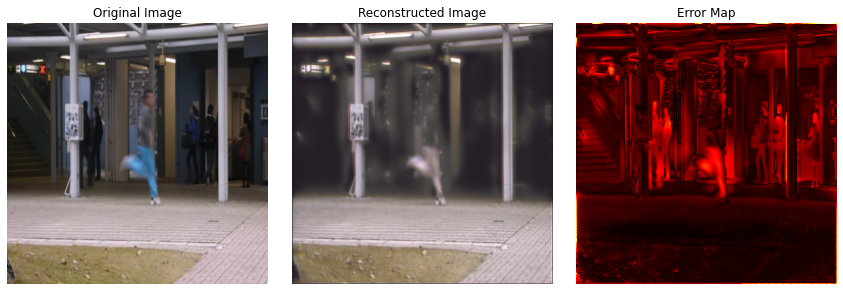

In [8]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Define a custom dataset for test data
class TestDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.image_paths = list(self.data_dir.glob("*.jpg")) + list(self.data_dir.glob("*.png"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, str(img_path)

# Load test dataset
def load_test_data(data_dir, batch_size=1):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize all images to 256x256
        transforms.ToTensor(),         # Convert images to PyTorch tensors
    ])
    dataset = TestDataset(data_dir, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return dataloader

# Function to visualize results
def visualize_results(original, reconstructed, error_map):
    plt.figure(figsize=(12, 4))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(original.permute(1, 2, 0).cpu().numpy())
    plt.title("Original Image")
    plt.axis("off")
    
    # Reconstructed Image
    plt.subplot(1, 3, 2)
    plt.imshow(reconstructed.permute(1, 2, 0).detach().cpu().numpy())
    plt.title("Reconstructed Image")
    plt.axis("off")
    
    # Error Map
    plt.subplot(1, 3, 3)
    plt.imshow(error_map.detach().cpu().numpy(), cmap="hot")
    plt.title("Error Map")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Test the model
def test_model(model, test_loader, device):
    model.eval()  # Set model to evaluation mode
    for images, img_paths in test_loader:
        images = images.to(device)
        with torch.no_grad():
            reconstructed = model(images)

        # Compute error map (L2 norm)
        error_map = torch.sqrt((images - reconstructed)**2).mean(dim=1, keepdim=False)

        # Visualize results for the first batch
        visualize_results(images[0], reconstructed[0], error_map[0])

        # Break after first batch (visualize one sample at a time)
        break

if __name__ == "__main__":
    # Parameters
    test_data_dir = r"C:\Users\uceti\Desktop\SIP\Datasets\Avenue\Abnormal\original"  # Replace with the path to your test data directory
    batch_size = 1  # Process one image at a time for visualization
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load the trained model (adjust model parameters as needed)
    input_channels = 3  # For RGB images
    model = Autoencoder(input_channels).to(device)
    model.load_state_dict(torch.load("Attention_with_eidetic.pth", map_location=device))  # Load trained model

    # Load test data
    test_loader = load_test_data(test_data_dir, batch_size=batch_size)

    # Test and visualize
    test_model(model, test_loader, device)


In [52]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms import ToPILImage

# Define a custom dataset for test data
class TestDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.image_paths = list(self.data_dir.glob("*.jpg")) + list(self.data_dir.glob("*.png"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, str(img_path)

# Load test dataset
def load_test_data(data_dir, batch_size=1):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize all images to 256x256
        transforms.ToTensor(),         # Convert images to PyTorch tensors
    ])
    dataset = TestDataset(data_dir, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return dataloader

# Function to save reconstructed and error maps
def save_results(original, reconstructed, error_map, img_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    reconstructed_dir = os.path.join(output_dir, "reconstructed")
    error_map_dir = os.path.join(output_dir, "error_maps")
    os.makedirs(reconstructed_dir, exist_ok=True)
    os.makedirs(error_map_dir, exist_ok=True)

    # Convert tensors to PIL images
    to_pil = ToPILImage()
    reconstructed_image = to_pil(reconstructed.cpu().detach())
    error_map_image = to_pil((error_map / error_map.max()).cpu().detach())  # Normalize error map for visualization

    # Save images
    base_name = Path(img_path).stem
    reconstructed_image.save(os.path.join(reconstructed_dir, f"{base_name}_reconstructed.png"))
    error_map_image.save(os.path.join(error_map_dir, f"{base_name}_error_map.png"))

# Test the model and save results
def test_model_and_save(model, test_loader, device, output_dir):
    model.eval()  # Set model to evaluation mode
    for images, img_paths in test_loader:
        images = images.to(device)
        with torch.no_grad():
            reconstructed = model(images)

        # Compute error map (L2 norm)
        error_map = torch.sqrt((images - reconstructed) ** 2).mean(dim=1, keepdim=False)

        # Save results for each image in the batch
        for i in range(images.size(0)):
            save_results(
                original=images[i],
                reconstructed=reconstructed[i],
                error_map=error_map[i],
                img_path=img_paths[i],
                output_dir=output_dir
            )

if __name__ == "__main__":
    # Parameters
    test_data_dir = r"C:\Users\uceti\Desktop\SIP\Datasets\Avenue\Abnormal\original"  # Replace with the path to your test data directory
    output_dir = "Maps"  # Replace with the path to save results
    batch_size = 1  # Process one image at a time
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load the trained model (adjust model parameters as needed)
    input_channels = 3  # For RGB images
    model = Autoencoder(input_channels).to(device)
    model.load_state_dict(torch.load("modified_AE_withattention.pth", map_location=device))  # Load trained model

    # Load test data
    test_loader = load_test_data(test_data_dir, batch_size=batch_size)

    # Test and save results
    test_model_and_save(model, test_loader, device, output_dir)
